In [1]:
pip install deap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

In [3]:
def eval_func(individual):
    x, y = individual
    return (-(x**2 + y**2) + 10,)

In [4]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Attribute generator (bounded)
toolbox.register("attr_float", random.uniform, -10, 10)

# Individual & population
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, 2)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [5]:
# Mutation with boundary control
def bounded_mutation(individual):
    for i in range(2):
        individual[i] += random.gauss(0, 1)
        individual[i] = np.clip(individual[i], -10, 10)
    return (individual,)

# Crossover with boundary control
def bounded_crossover(ind1, ind2):
    tools.cxBlend(ind1, ind2, alpha=0.5)
    
    for i in range(2):
        ind1[i] = np.clip(ind1[i], -10, 10)
        ind2[i] = np.clip(ind2[i], -10, 10)
    
    return ind1, ind2

In [6]:
toolbox.register("evaluate", eval_func)
toolbox.register("mate", bounded_crossover)
toolbox.register("mutate", bounded_mutation)
toolbox.register("select", tools.selTournament, tournsize=3)

# Jupyter-safe mapping
toolbox.register("map", map)

In [7]:
population = toolbox.population(n=20)

NGEN = 20
CXPB = 0.7
MUTPB = 0.2

fitness_history = []

for gen in range(NGEN):
    offspring = algorithms.varAnd(population, toolbox, cxpb=CXPB, mutpb=MUTPB)
    
    fits = list(toolbox.map(toolbox.evaluate, offspring))
    
    for fit, ind in zip(fits, offspring):
        ind.fitness.values = fit
    
    population = toolbox.select(offspring, k=len(population))
    
    best = tools.selBest(population, 1)[0]
    fitness_history.append(best.fitness.values[0])
    
    print(f"Gen {gen+1}, Best: ({best[0]:.2f}, {best[1]:.2f}), Fitness: {best.fitness.values[0]:.4f}")

Gen 1, Best: (-0.75, 2.37), Fitness: 3.8411
Gen 2, Best: (-0.23, 0.80), Fitness: 9.3125
Gen 3, Best: (-0.23, 0.80), Fitness: 9.3125
Gen 4, Best: (-0.25, 0.41), Fitness: 9.7654
Gen 5, Best: (-0.36, -0.14), Fitness: 9.8483
Gen 6, Best: (-0.36, -0.14), Fitness: 9.8483
Gen 7, Best: (-0.35, -0.09), Fitness: 9.8721
Gen 8, Best: (-0.21, 0.02), Fitness: 9.9563
Gen 9, Best: (-0.21, 0.02), Fitness: 9.9563
Gen 10, Best: (-0.14, 0.04), Fitness: 9.9790
Gen 11, Best: (-0.14, 0.04), Fitness: 9.9790
Gen 12, Best: (-0.14, -0.02), Fitness: 9.9791
Gen 13, Best: (-0.14, -0.03), Fitness: 9.9797
Gen 14, Best: (-0.14, -0.02), Fitness: 9.9802
Gen 15, Best: (-0.12, -0.00), Fitness: 9.9866
Gen 16, Best: (-0.11, 0.01), Fitness: 9.9887
Gen 17, Best: (-0.10, 0.00), Fitness: 9.9896
Gen 18, Best: (-0.10, 0.00), Fitness: 9.9896
Gen 19, Best: (-0.10, 0.00), Fitness: 9.9901
Gen 20, Best: (-0.10, 0.00), Fitness: 9.9906


In [8]:
best = tools.selBest(population, 1)[0]

print("\nFinal Best Solution:", best[0])
print("Final Fitness:", best.fitness.values[0])


Final Best Solution: -0.09704929390585705
Final Fitness: 9.990580912576688


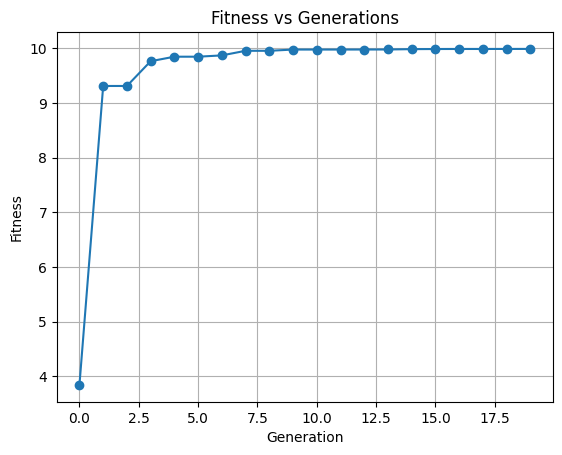

In [9]:
plt.plot(fitness_history, marker='o')
plt.title("Fitness vs Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid()
plt.show()